# Exploratory Data Analysis (EDA) of Compound-Gene Interactions
**Target Genes:** CYP450 Family

This notebook presents an exploratory analysis of compound interactions with five Cytochrome P450 enzymes (CYP1A2, CYP2C9, CYP2C19, CYP2D6, and CYP3A4). The dataset includes information on interaction types and actions extracted from a compound-gene interaction knowledge graph. This analysis supports understanding of interaction diversity, compound promiscuity, and interaction distribution.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [3]:
# Load the data
file_path = '../import/processed_compound_gene_interactions.csv'
data = pd.read_csv(file_path)
data.columns = [col.strip().replace(' ', '_') for col in data.columns]
data.head()

C:\Users\Asmaa_Ali\AppData\Local\Temp\ipykernel_8120\3599473118.py:3: DtypeWarning: Columns (53,54,55,56,57,58,59,60,61,62,64,65,66,67,68,70,71,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,Compound_IsomericSMILES,Compound_ExactMass,Compound_XStericQuadrupole3D,Compound_InChI,Compound_FeatureCationCount3D,Compound_IsotopeAtomCount,Compound_IUPACName,Compound_Volume3D,Compound_PatentFamilyCount,Compound_StructureImage2DURL,...,Interaction_protname,Interaction_dois,Interaction_evurls,Interaction_protacxn,Interaction_srccmpdname,Interaction_id,Interaction_srctarget,Interaction_dsn,Interaction_actname,Interaction_action
0,COC1=NC=C(C=N1)C2=CC3=C(NC=C3C(=O)C4=C(C=CC(=C...,557.078088,20.53,InChI=1S/C25H15F4N5O4S/c1-38-25-32-9-13(10-33-...,2.0,0,"N-[2,4-difluoro-3-[5-(2-methoxypyrimidin-5-yl)...",391.1,1.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CN1CCN(CC1)CC2=C(C=CC(=C2)NC3=C4C=C(C=CC4=NC5=...,462.182254,9.35,InChI=1S/C26H27ClN4O2/c1-30-9-11-31(12-10-30)1...,3.0,0,4-[(6-chloro-2-methoxyacridin-9-yl)amino]-2-[(...,354.3,6.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,COC(=O)N[C@H](C1=CC=CC=C1)C(=O)N2CCC[C@H]2C(=O...,796.303219,NaN,InChI=1S/C42H42F2N6O8/c1-57-41(55)47-35(25-11-...,NaN,0,methyl N-[(1R)-2-[(2S)-2-[[3-fluoro-4-[2-fluor...,NaN,1.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CC(C)C[C@@H](C(=O)N[C@@H](C[C@@H]1CCNC1=O)C(=O...,575.220240,22.32,InChI=1S/C30H33N5O5S/c1-16(2)13-22(34-29(39)23...,1.0,0,"N-[(2S)-1-[[(2S)-1-(1,3-benzothiazol-2-yl)-1-o...",441.9,3.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CN1C[C@H]2CCCC[C@]2(C1)C3=CC(=C(C=C3)Cl)Cl,283.089455,7.34,"InChI=1S/C15H19Cl2N/c1-18-9-12-4-2-3-7-15(12,1...",1.0,0,"(3aS,7aR)-7a-(3,4-dichlorophenyl)-2-methyl-3,3...",211.6,1.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Preprocessing: Filter for relevant genes and clean interaction types
required_columns = ['Gene_GeneSymbol', 'InteractionType', 'Interaction_action', 'Compound_CompoundID']
for col in required_columns:
    assert col in data.columns, f'Missing column: {col}'

data['InteractionType'] = data['InteractionType'].str.lower()
data['Interaction_action'] = data['Interaction_action'].str.lower()
mask = (data['InteractionType'] == 'interacts_with') & (data['Interaction_action'].str.len() < 20)
data.loc[mask, 'InteractionType'] = data.loc[mask, 'Interaction_action']
excluded_interactions = ['inhibitororsubstrate', 'inhibitororinducerormodulator', 'interacts_with']
data = data[~data.InteractionType.isin(excluded_interactions)]
specified_genes = ['CYP1A2', 'CYP2C9', 'CYP2C19', 'CYP2D6', 'CYP3A4']
data = data[data['Gene_GeneSymbol'].isin(specified_genes)]
data.shape

(282269, 74)

In [5]:
# Descriptive statistics of numeric columns (if any)
data.describe(include='all')

,Compound_IsomericSMILES,Compound_ExactMass,Compound_XStericQuadrupole3D,Compound_InChI,Compound_FeatureCationCount3D,Compound_IsotopeAtomCount,Compound_IUPACName,Compound_Volume3D,Compound_PatentFamilyCount,Compound_StructureImage2DURL,...,Interaction_protname,Interaction_dois,Interaction_evurls,Interaction_protacxn,Interaction_srccmpdname,Interaction_id,Interaction_srctarget,Interaction_dsn,Interaction_actname,Interaction_action
count,282269,282269.000000,262684.000000,282269,262684.000000,282269.000000,282048,262684.000000,78613.000000,282269,...,1263,6,979,1263,1263,1.263000e+03,1263,1263,17,1263
unique,120964,NaN,NaN,120946,NaN,NaN,120890,NaN,NaN,120968,...,5,1,752,5,817,NaN,16,6,3,6
top,CC1=C(N=CN1)CSCCNC(=NC)NC#N,NaN,NaN,InChI=1S/C10H16N6S/c1-8-9(16-7-15-8)5-17-4-3-1...,NaN,NaN,"3-[(1R,2S)-2-amino-1-hydroxypropyl]phenol;(2R,...",NaN,NaN,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,Cytochrome P450 3A4,['10.1021/jm060519r'],https://www.ncbi.nlm.nih.gov/pubmed/22039822,P08684,Zolpidem,NaN,BE0002638,DrugBank,pIC50,substrate
freq,15,NaN,NaN,15,NaN,NaN,20,NaN,NaN,15,...,443,6,20,443,5,NaN,363,1060,9,718
mean,NaN,346.218972,13.175604,NaN,0.726569,0.000188,NaN,258.501259,4300.768524,NaN,...,NaN,NaN,NaN,NaN,NaN,1.186274e+06,NaN,NaN,NaN,NaN
std,NaN,108.111712,6.660422,NaN,0.883684,0.026684,NaN,69.270059,15849.016385,NaN,...,NaN,NaN,NaN,NaN,NaN,6.768748e+05,NaN,NaN,NaN,NaN
min,NaN,30.010565,0.930000,NaN,0.000000,0.000000,NaN,25.200000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,4.523000e+03,NaN,NaN,NaN,NaN
25%,NaN,282.136828,8.420000,NaN,0.000000,0.000000,NaN,215.300000,2.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,4.716000e+05,NaN,NaN,NaN,NaN
50%,NaN,343.130775,11.820000,NaN,0.000000,0.000000,NaN,259.200000,82.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,1.349613e+06,NaN,NaN,NaN,NaN
75%,NaN,406.164105,16.590000,NaN,1.000000,0.000000,NaN,304.500000,2615.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,1.867156e+06,NaN,NaN,NaN,NaN


In [6]:
# Count of each interaction type per gene
interaction_counts = data.groupby(['Gene_GeneSymbol', 'InteractionType']).size().reset_index(name='Count')
interaction_counts

,Gene_GeneSymbol,InteractionType,Count
0,CYP1A2,inactive,9015
1,CYP1A2,inducer,16
2,CYP1A2,inhibition,1
3,CYP1A2,inhibitor,7636
4,CYP1A2,product of,1
5,CYP1A2,substrate,104
6,CYP2C19,activator,1
7,CYP2C19,inactive,102028
8,CYP2C19,inducer,17
9,CYP2C19,inhibition,2


In [7]:
# Count compounds with "INTERACTS_WITH" and another relationship
interacts_with_data = data[data["InteractionType"] == "interacts_with"]
other_relationship_data = data[data["InteractionType"] != "interacts_with"]

compound_gene_interactions = pd.merge(
    interacts_with_data,
    other_relationship_data,
    on=["Compound_CompoundID", "Gene_GeneSymbol"],
    suffixes=("_interacts", "_other"),
)
compounds_with_multiple_relationships = compound_gene_interactions[
    "Compound_CompoundID"
].nunique()
print(
    f"Compounds with 'INTERACTS_WITH' and another relationship: {compounds_with_multiple_relationships}"
)
compound_gene_interactions

Compounds with 'INTERACTS_WITH' and another relationship: 0


,Compound_IsomericSMILES_interacts,Compound_ExactMass_interacts,Compound_XStericQuadrupole3D_interacts,Compound_InChI_interacts,Compound_FeatureCationCount3D_interacts,Compound_IsotopeAtomCount_interacts,Compound_IUPACName_interacts,Compound_Volume3D_interacts,Compound_PatentFamilyCount_interacts,Compound_StructureImage2DURL_interacts,...,Interaction_protname_other,Interaction_dois_other,Interaction_evurls_other,Interaction_protacxn_other,Interaction_srccmpdname_other,Interaction_id_other,Interaction_srctarget_other,Interaction_dsn_other,Interaction_actname_other,Interaction_action_other


In [8]:
# Count unique genes each compound interacts with
compound_gene_count = (
    data.groupby("Compound_CompoundID")["Gene_GeneSymbol"]
    .nunique()
    .reset_index(name="UniqueGeneCount")
)
compound_gene_count

,Compound_CompoundID,UniqueGeneCount
0,4,5
1,6,3
2,11,5
3,13,5
4,33,4
...,...,...
120963,171357078,1
120964,171358533,1
120965,171358589,1
120966,171358782,1


In [9]:
# 1. Compounds interacting with all specified genes
compounds_with_all_genes = compound_gene_count[
    compound_gene_count["UniqueGeneCount"] == len(specified_genes)
]
num_compounds_with_all_genes = compounds_with_all_genes.shape[0]
print(f"Compounds interacting with all genes: {num_compounds_with_all_genes}")
compounds_with_all_genes

Compounds interacting with all genes: 8106


,Compound_CompoundID,UniqueGeneCount
0,4,5
2,11,5
3,13,5
5,34,5
6,51,5
...,...,...
120864,166642340,5
120865,166642341,5
120875,167427876,5
120912,168297478,5


In [11]:
# 2. Compounds interacting with at least one gene
num_compounds_with_at_least_one_gene = compound_gene_count[
    (compound_gene_count["UniqueGeneCount"] > 1)
    & (compound_gene_count["UniqueGeneCount"] < 5)
].shape[0]
print(
    f"Compounds interacting with at least one gene: {num_compounds_with_at_least_one_gene}"
)

Compounds interacting with at least one gene: 103947


In [13]:
# 3. Compounds interacting with exactly one gene
num_compounds_with_one_gene = compound_gene_count[
    compound_gene_count["UniqueGeneCount"] == 1
].shape[0]
print(f"Compounds interacting with exactly one gene: {num_compounds_with_one_gene}")

# Save these stats
compound_gene_count

Compounds interacting with exactly one gene: 8915


,Compound_CompoundID,UniqueGeneCount
0,4,5
1,6,3
2,11,5
3,13,5
4,33,4
...,...,...
120963,171357078,1
120964,171358533,1
120965,171358589,1
120966,171358782,1


In [14]:
# Interaction counts by type and gene
interaction_counts = (
    data.groupby(["Gene_GeneSymbol", "InteractionType"])
    .size()
    .reset_index(name="Count")
)
interaction_counts


,Gene_GeneSymbol,InteractionType,Count
0,CYP1A2,inactive,9015
1,CYP1A2,inducer,16
2,CYP1A2,inhibition,1
3,CYP1A2,inhibitor,7636
4,CYP1A2,product of,1
5,CYP1A2,substrate,104
6,CYP2C19,activator,1
7,CYP2C19,inactive,102028
8,CYP2C19,inducer,17
9,CYP2C19,inhibition,2


In [15]:
# Descriptive statistics for numeric fields
numeric_cols = data.select_dtypes(include=["float64", "int64"]).columns
numeric_stats = data[numeric_cols].describe()
numeric_stats

,Compound_ExactMass,Compound_XStericQuadrupole3D,Compound_FeatureCationCount3D,Compound_IsotopeAtomCount,Compound_Volume3D,Compound_PatentFamilyCount,Compound_Complexity,Compound_PatentCount,Compound_FeatureHydrophobeCount3D,Compound_MonoisotopicMass,...,Compound_XLogP,Compound_EffectiveRotorCount3D,Compound_AtomStereoCount,Compound_ConformerModelRMSD3D,Compound_FeatureAcceptorCount3D,Gene_TaxonomyID,Gene_GeneID,Interaction_AssayID,Interaction_taxid,Interaction_id
count,282269.000000,262684.000000,262684.000000,282269.000000,262684.000000,78613.000000,282269.000000,7.861300e+04,262684.000000,282269.000000,...,265939.000000,262684.000000,282269.000000,262684.000000,262684.000000,282269.0,282269.000000,2.810060e+05,1263.0,1.263000e+03
mean,346.218972,13.175604,0.726569,0.000188,258.501259,4300.768524,482.940060,1.231387e+04,0.316228,346.205392,...,2.786771,5.959531,0.640793,0.813532,2.764584,9606.0,1559.483560,2.856988e+05,9606.0,1.186274e+06
std,108.111712,6.660422,0.883684,0.026684,69.270059,15849.016385,218.633824,3.622998e+04,0.639210,108.100051,...,1.625715,2.791458,1.666505,0.217257,1.521851,0.0,6.783962,6.104961e+05,0.0,6.768748e+05
min,30.010565,0.930000,0.000000,0.000000,25.200000,1.000000,0.000000,1.000000e+00,0.000000,30.010565,...,-17.200000,0.000000,0.000000,0.400000,0.000000,9606.0,1544.000000,4.100000e+02,9606.0,4.523000e+03
25%,282.136828,8.420000,0.000000,0.000000,215.300000,2.000000,347.000000,7.000000e+00,0.000000,282.136828,...,1.900000,4.000000,0.000000,0.600000,2.000000,9606.0,1557.000000,1.024000e+03,9606.0,4.716000e+05
50%,343.130775,11.820000,0.000000,0.000000,259.200000,82.000000,469.000000,2.450000e+02,0.000000,343.128054,...,2.800000,6.000000,0.000000,0.800000,3.000000,9606.0,1559.000000,1.025000e+03,9606.0,1.349613e+06
75%,406.164105,16.590000,1.000000,0.000000,304.500000,2615.000000,603.000000,8.158000e+03,0.000000,406.164105,...,3.700000,8.000000,1.000000,1.000000,4.000000,9606.0,1559.000000,1.025000e+03,9606.0,1.867156e+06
max,1875.540932,99.010000,6.000000,6.000000,585.700000,963835.000000,3980.000000,1.476513e+06,11.000000,1875.540932,...,25.900000,18.000000,40.000000,2.000000,18.000000,9606.0,1576.000000,1.963537e+06,9606.0,2.170495e+06


## Figures

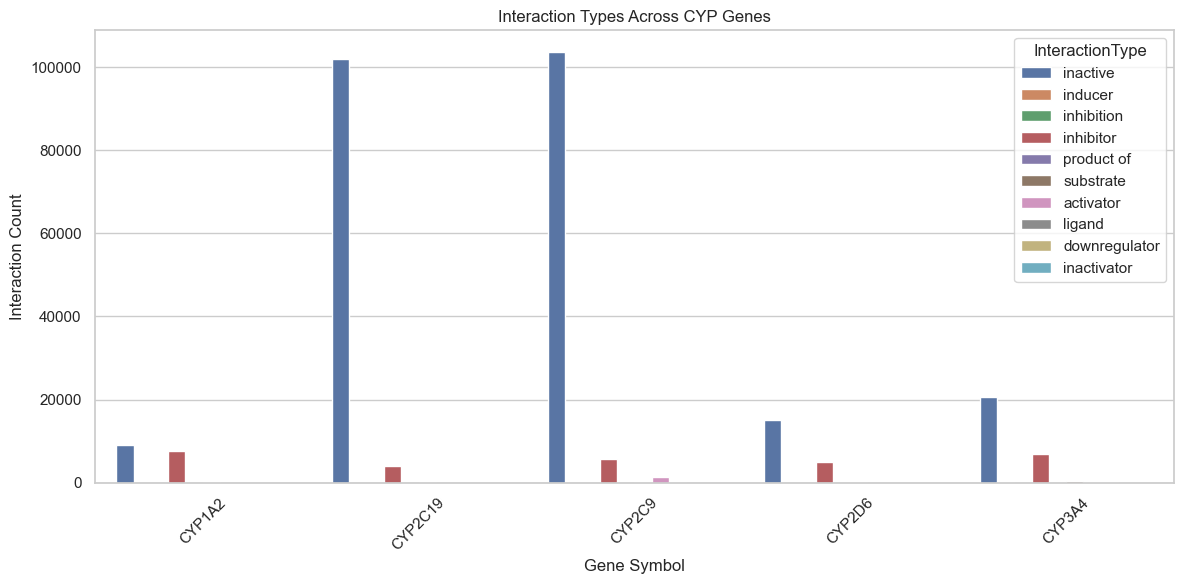

In [6]:
# Bar plot: Interaction counts by gene and type
plt.figure(figsize=(12, 6))
sns.barplot(data=interaction_counts, x='Gene_GeneSymbol', y='Count', hue='InteractionType')
plt.title('Interaction Types Across CYP Genes')
plt.xlabel('Gene Symbol')
plt.ylabel('Interaction Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

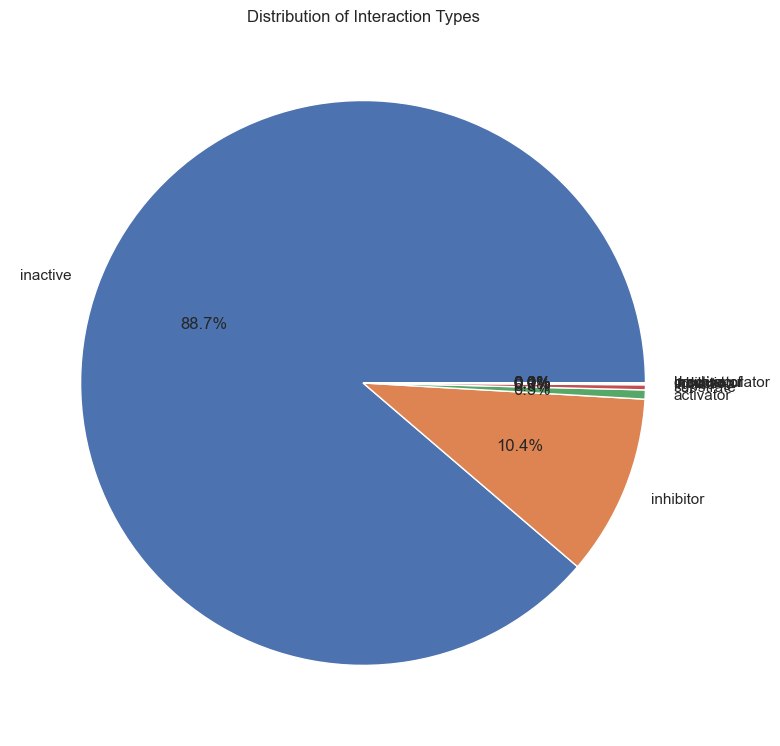

In [7]:
# Pie chart: Overall distribution of interaction types
interaction_type_distribution = data['InteractionType'].value_counts()
interaction_type_distribution.plot.pie(autopct='%.1f%%', figsize=(8, 8), title='Distribution of Interaction Types')
plt.ylabel('')
plt.tight_layout()
plt.show()

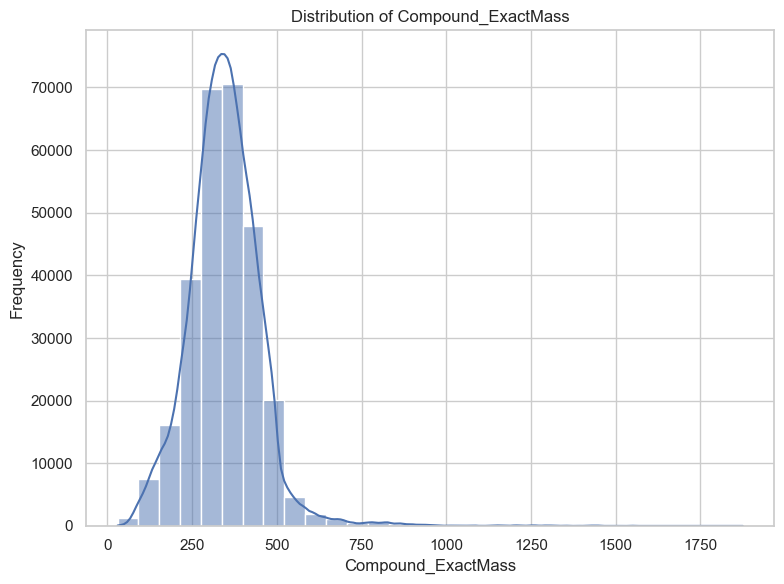

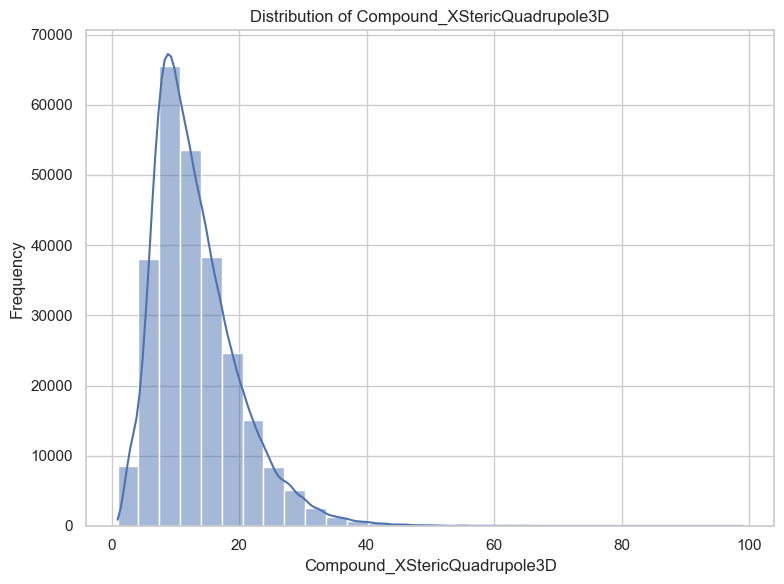

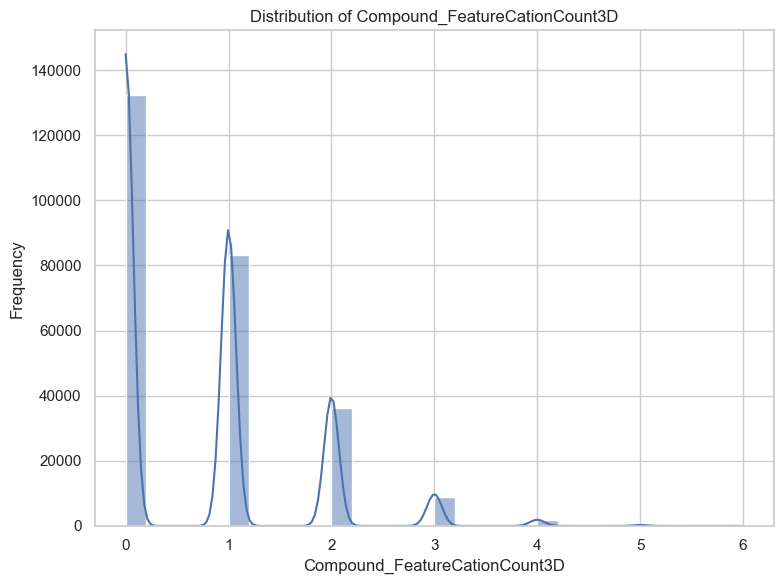

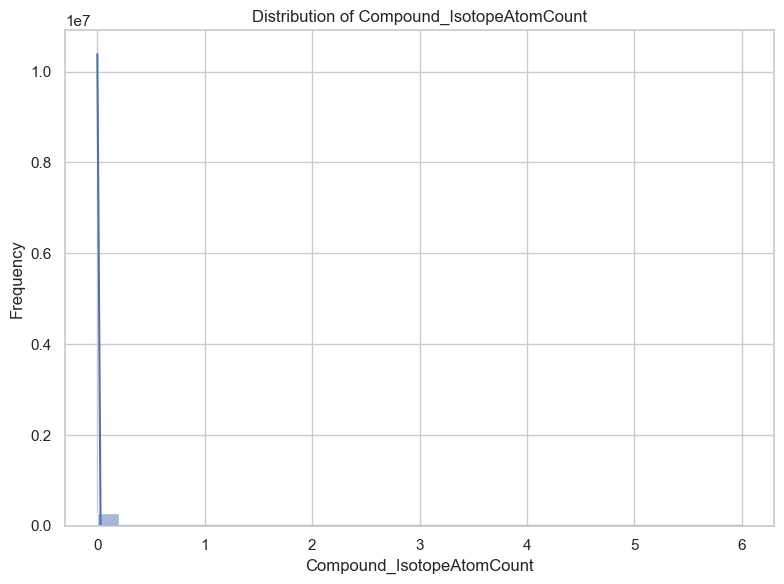

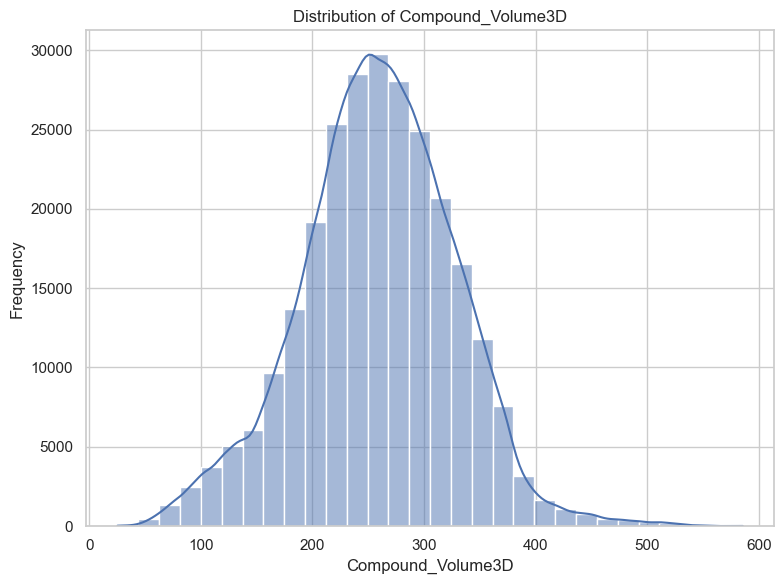

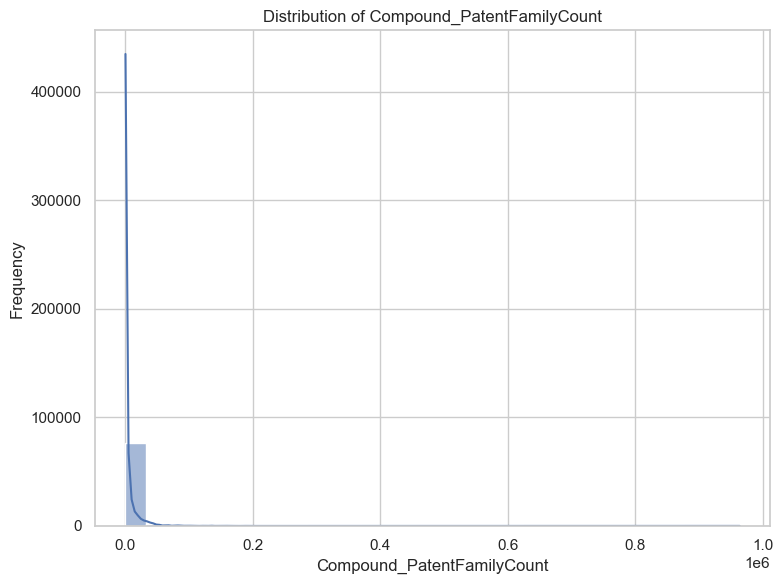

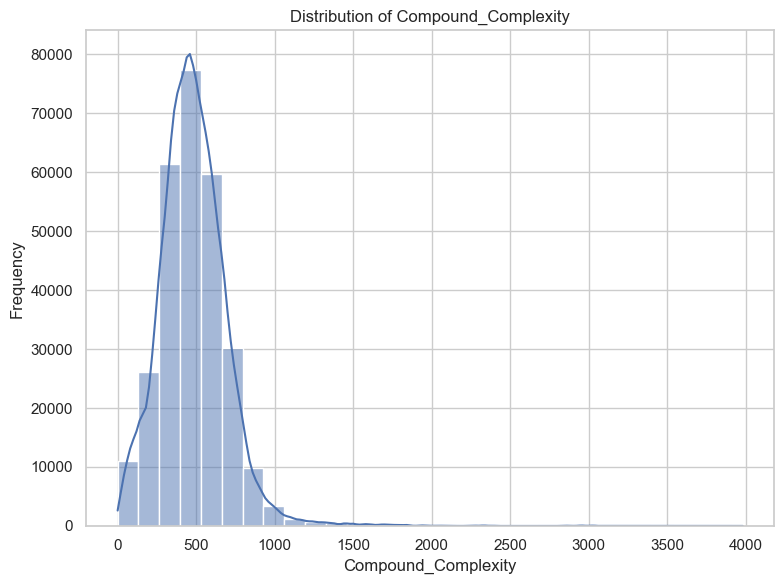

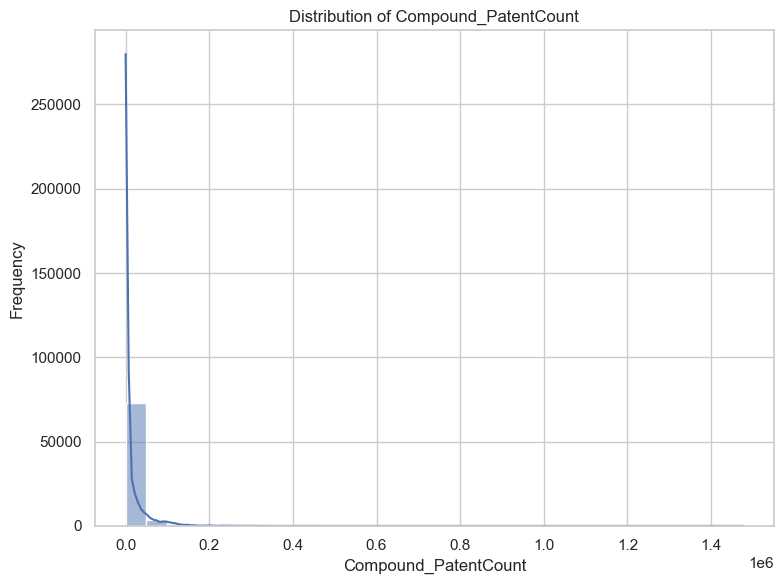

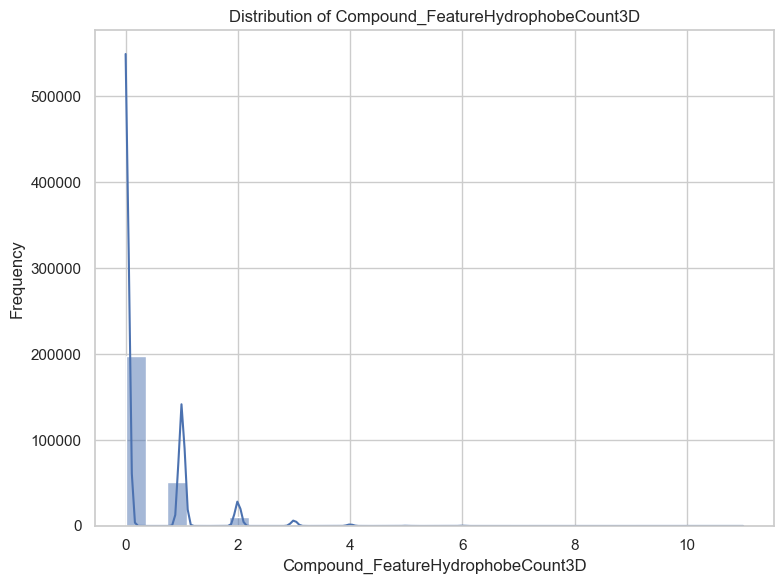

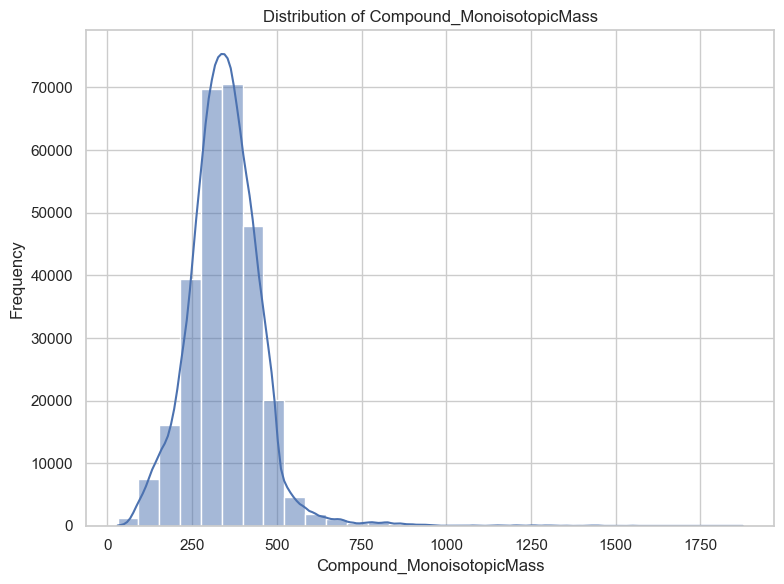

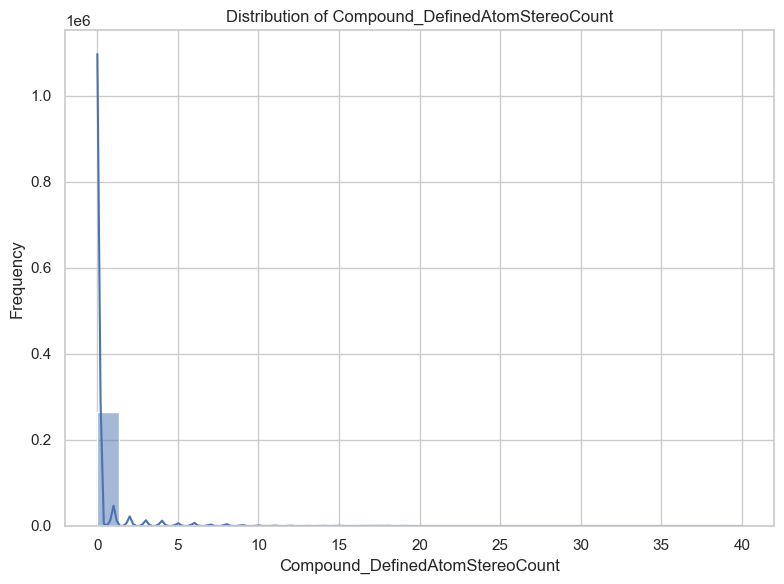

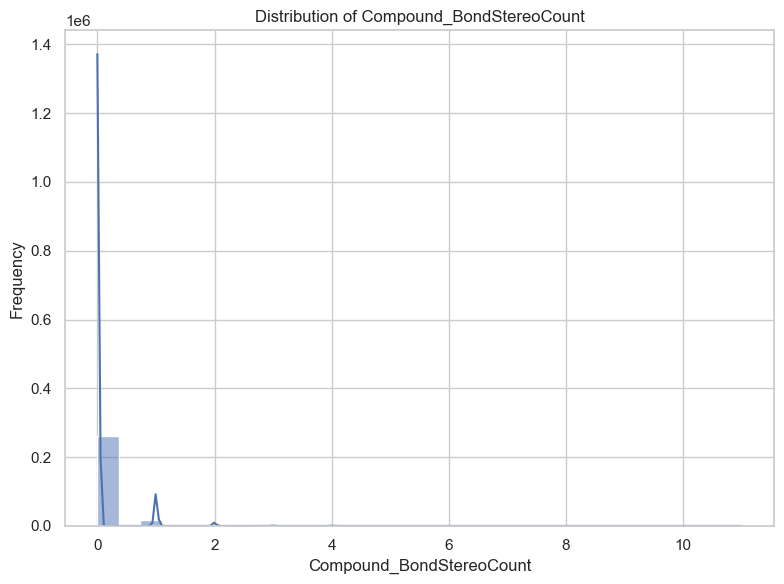

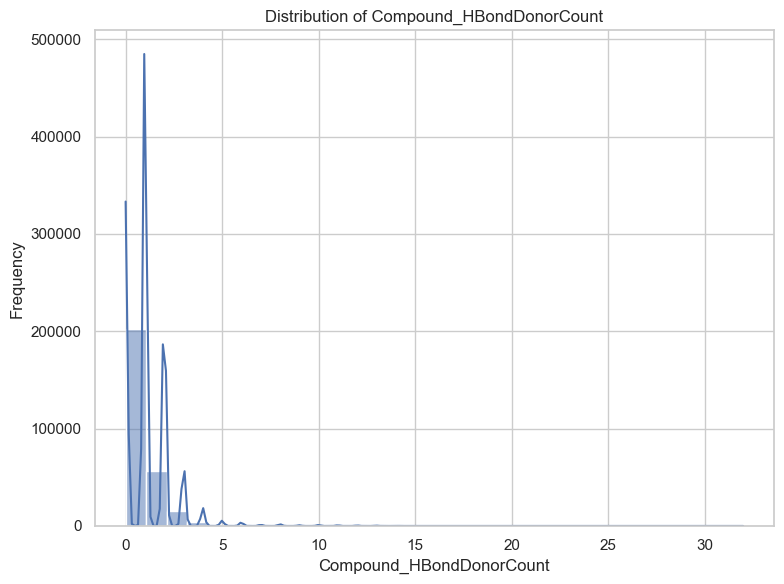

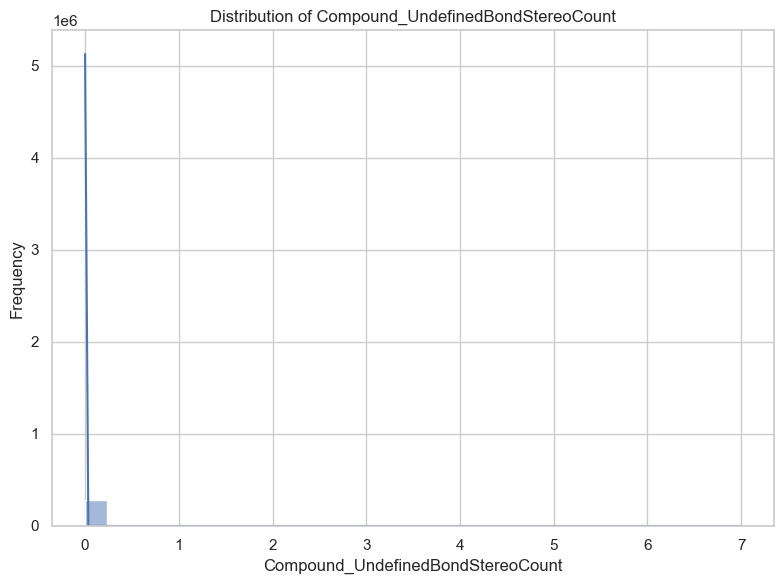

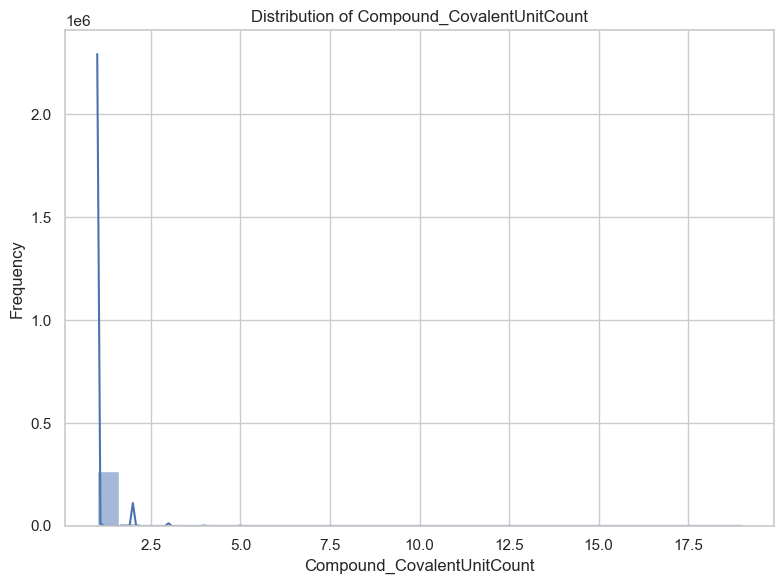

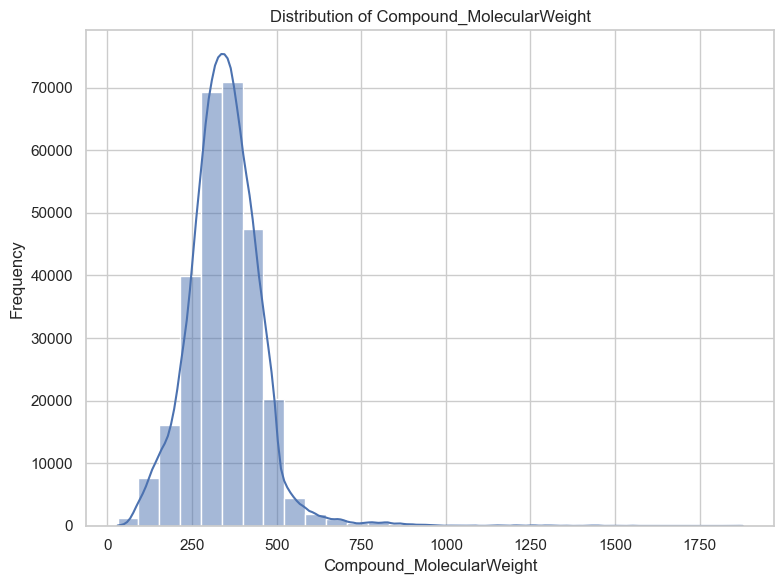

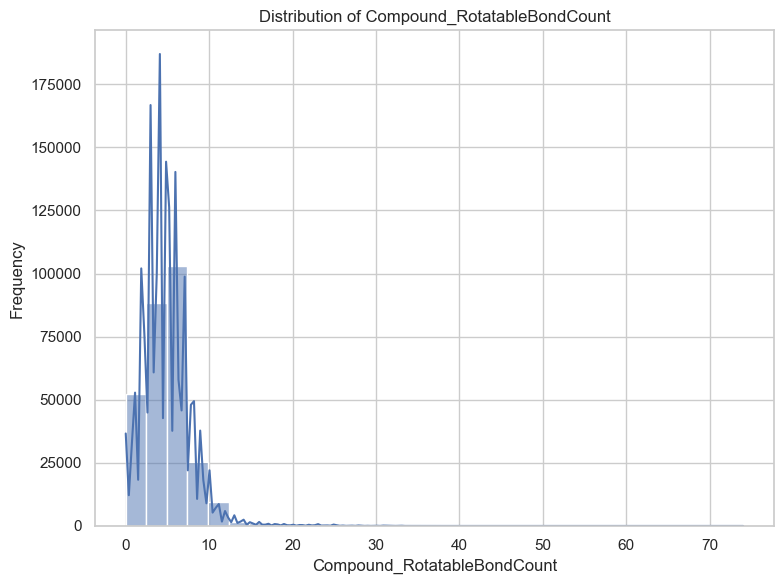

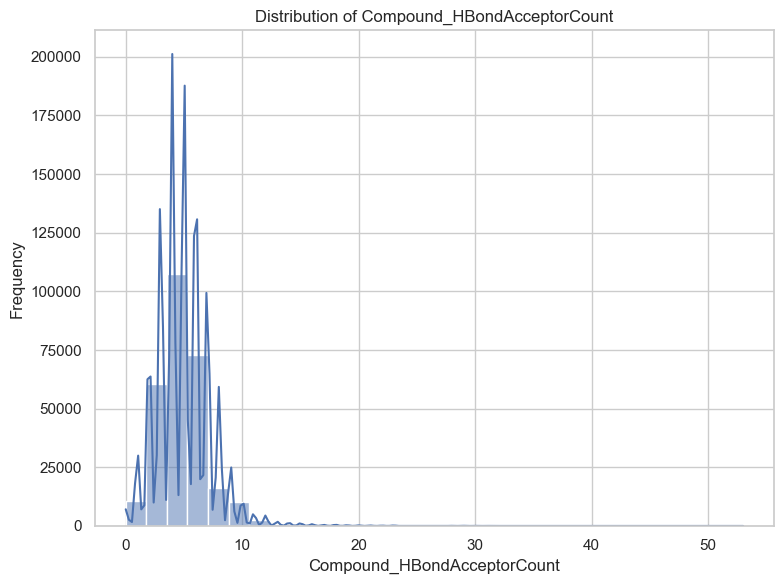

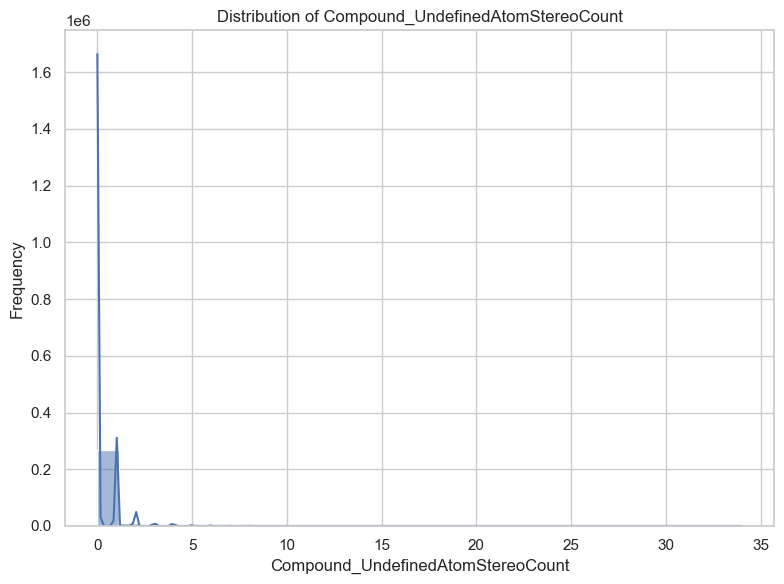

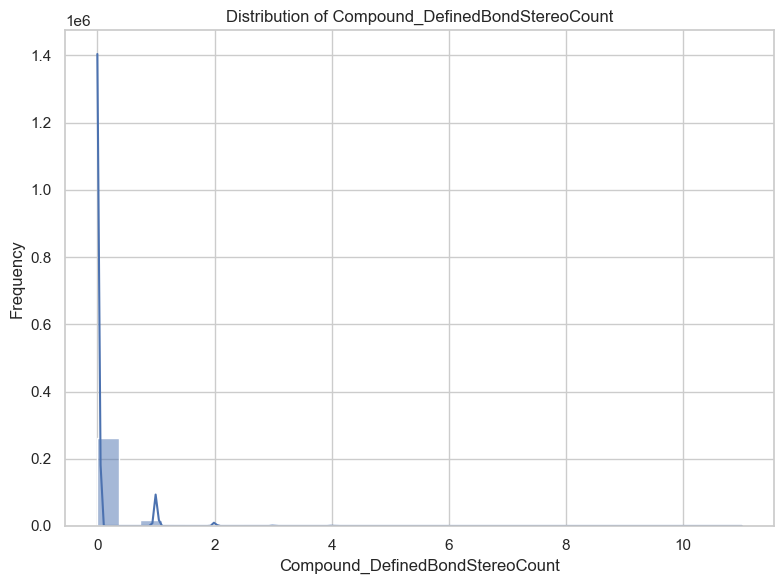

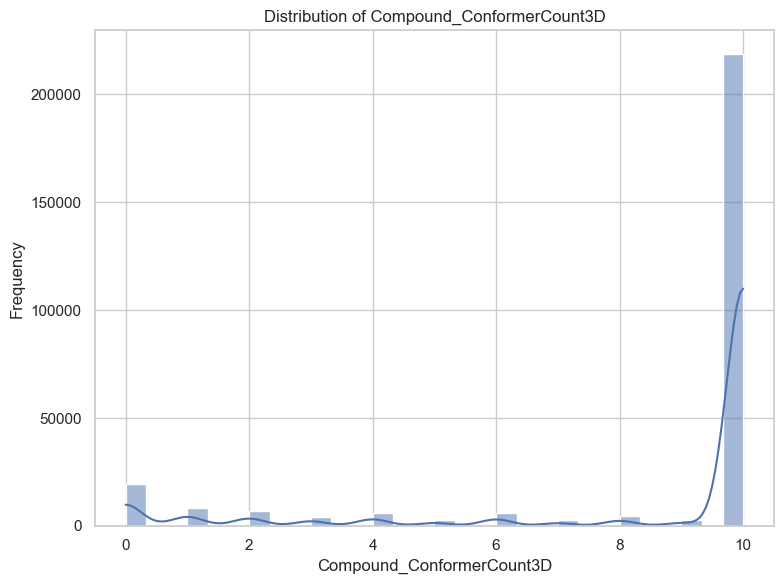

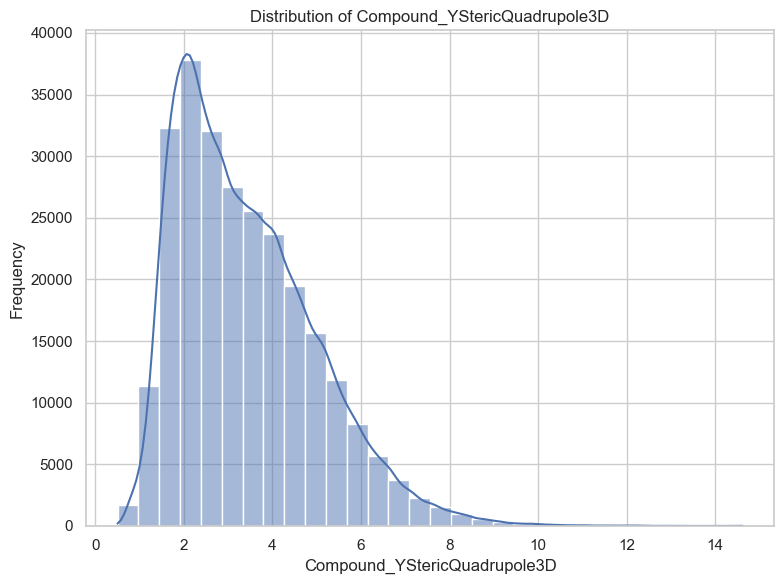

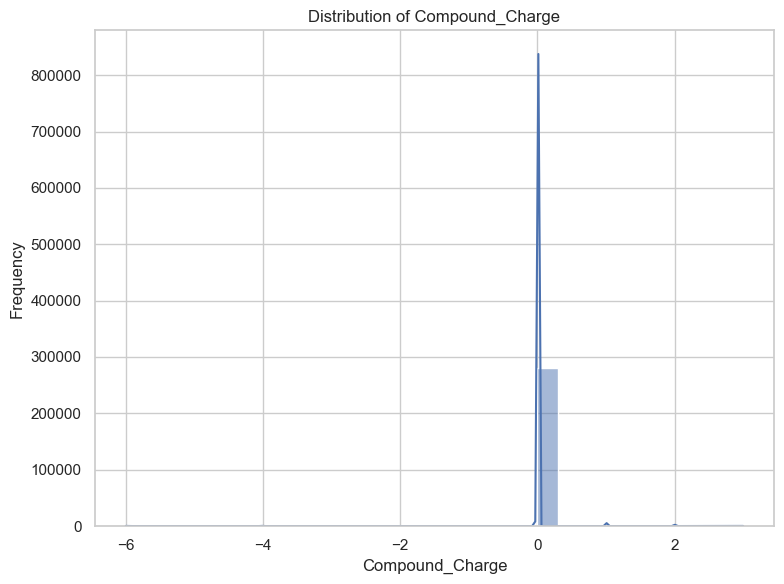

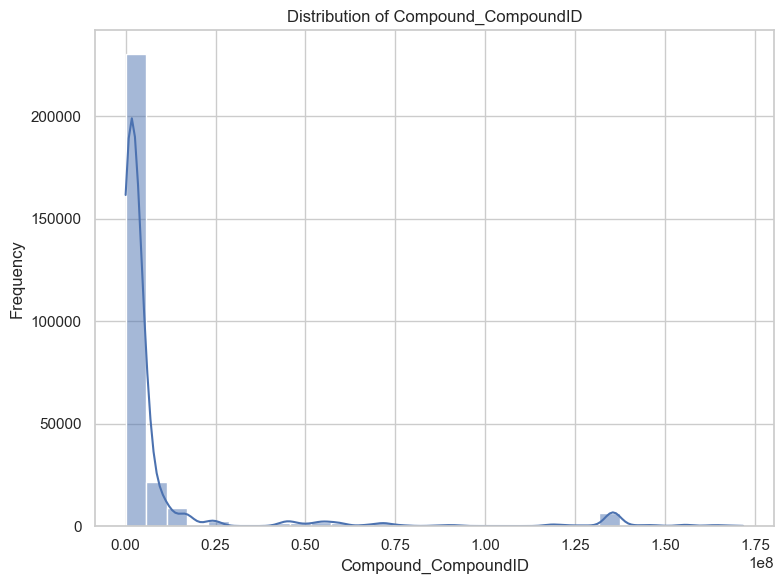

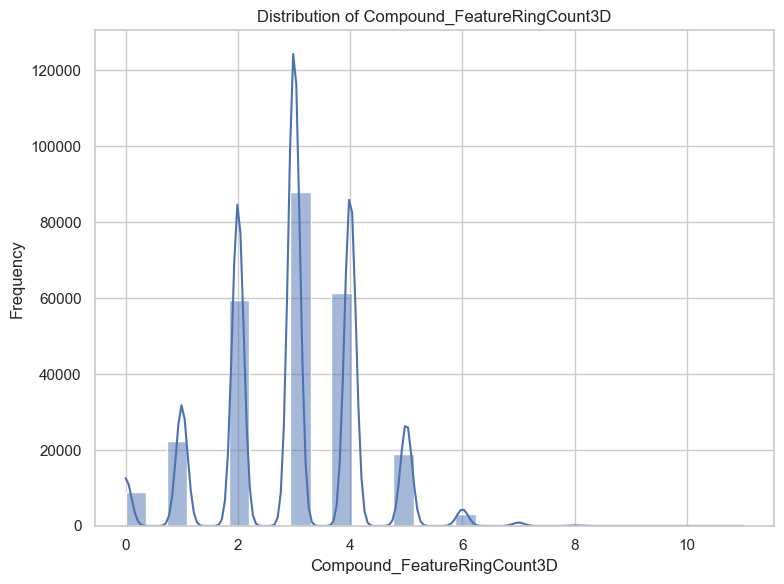

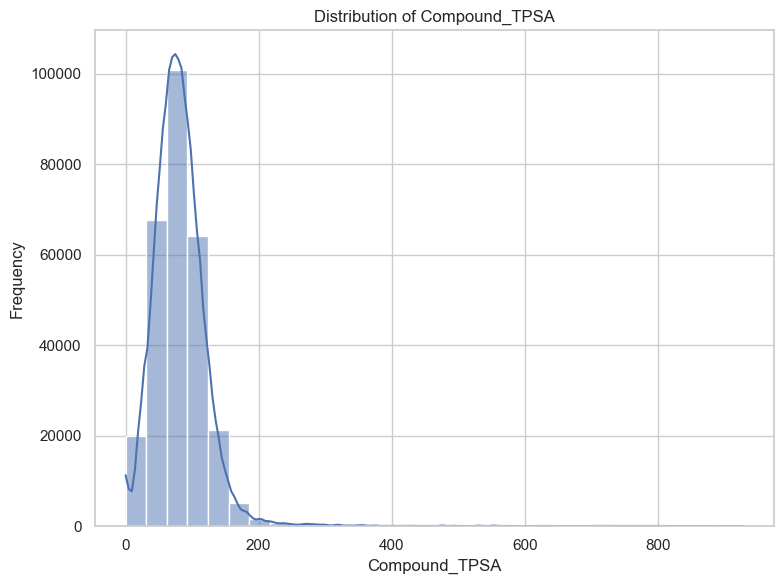

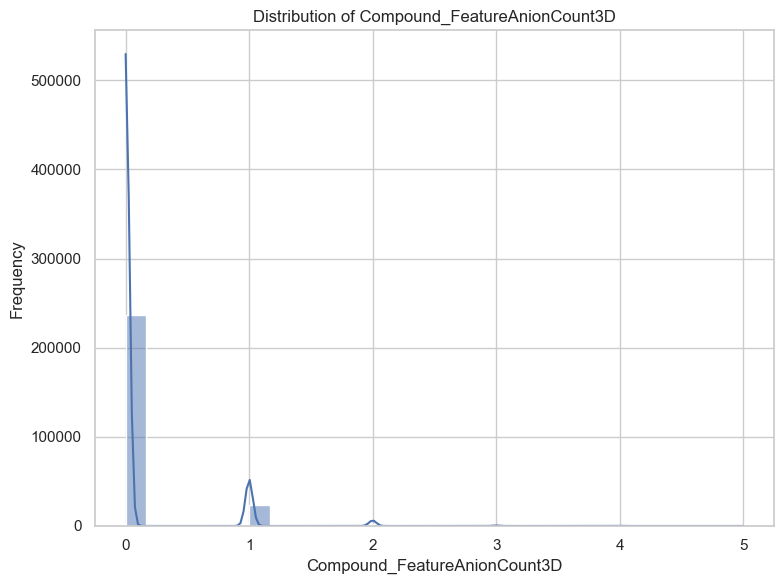

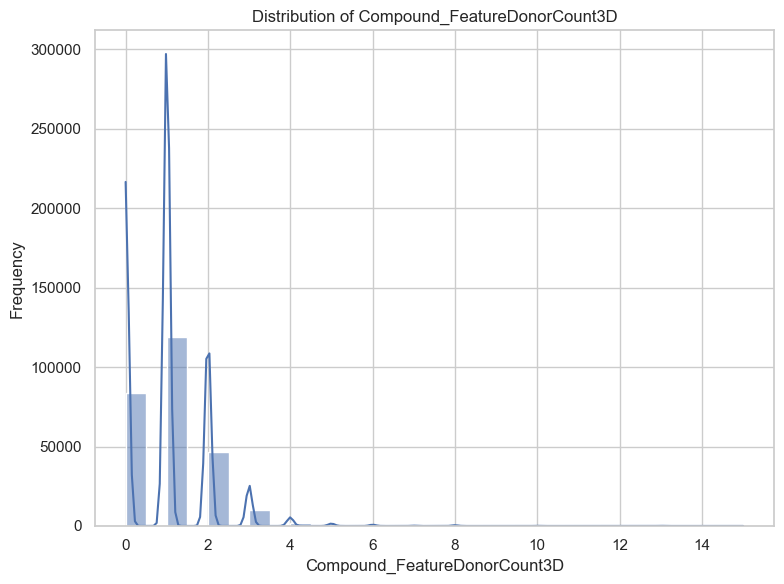

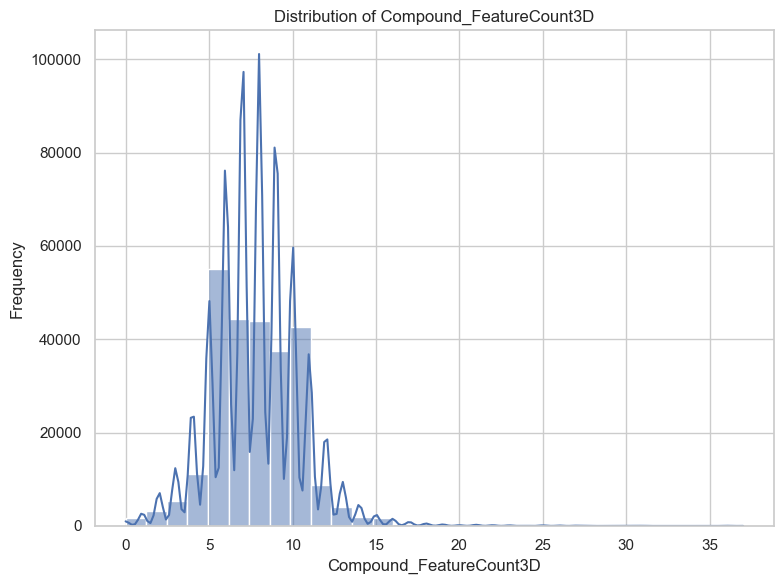

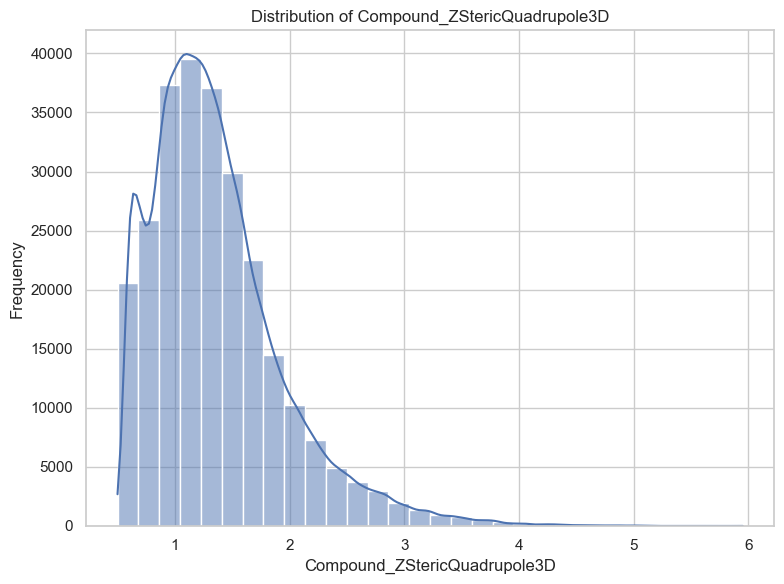

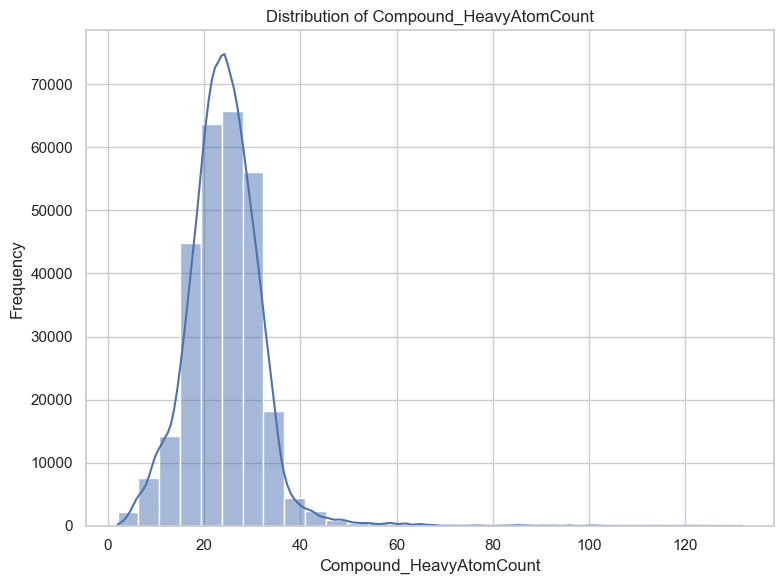

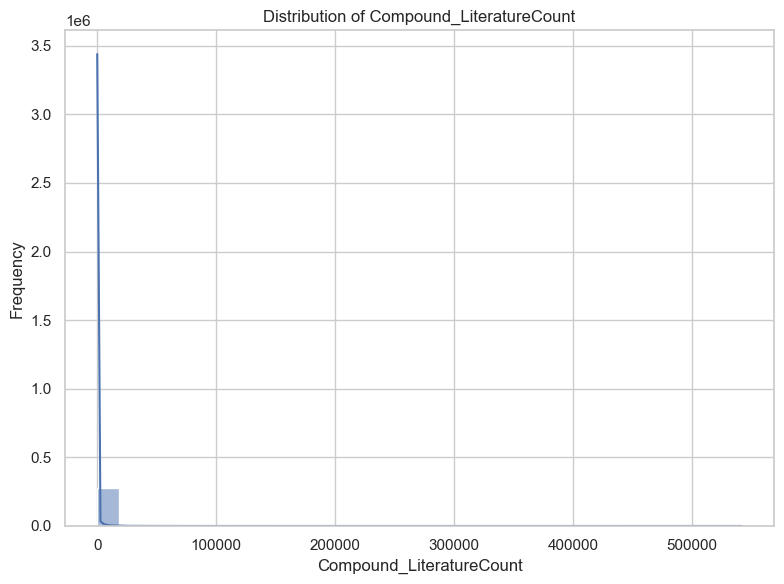

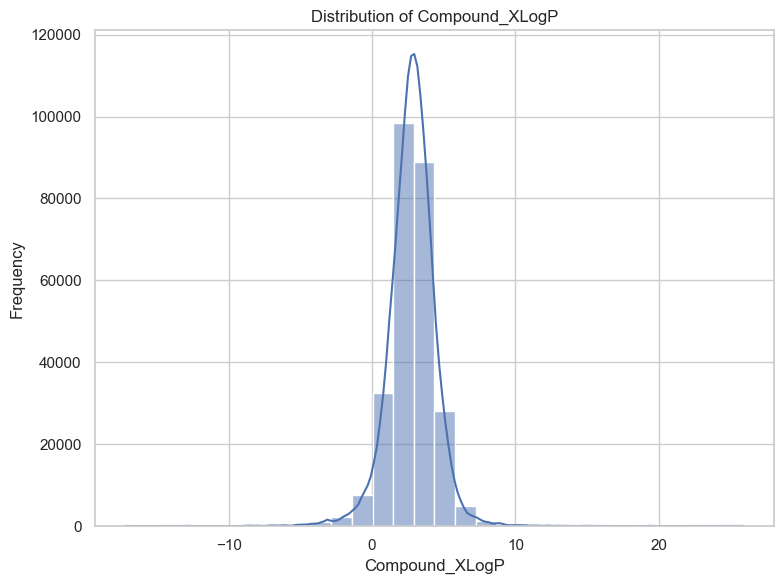

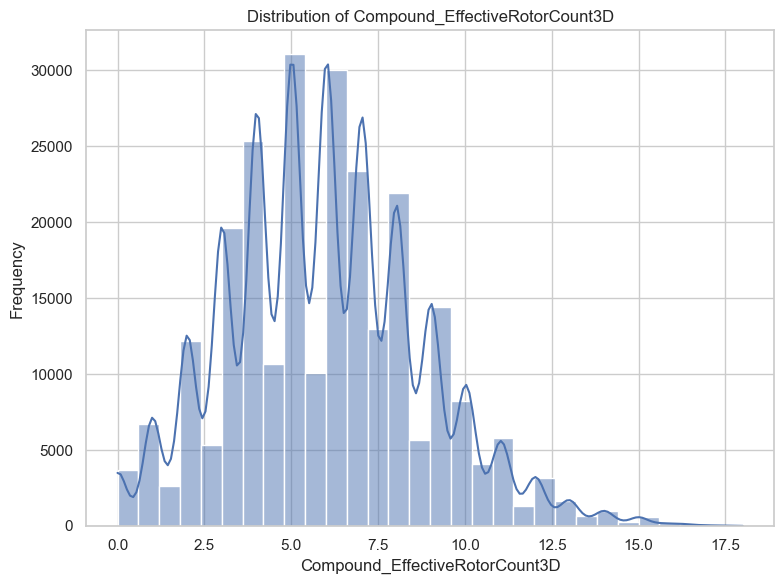

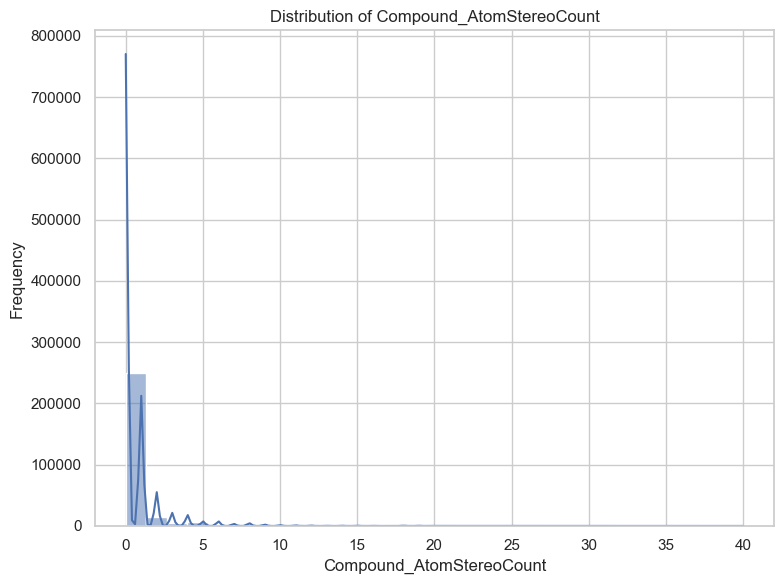

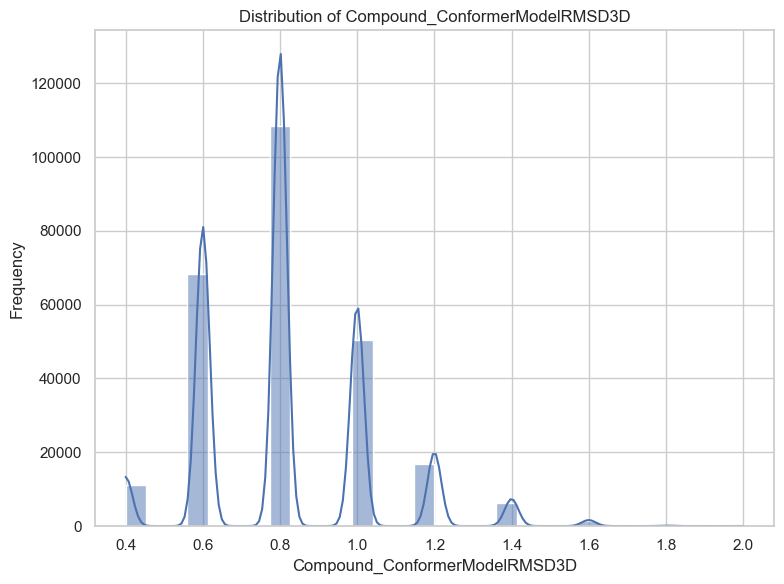

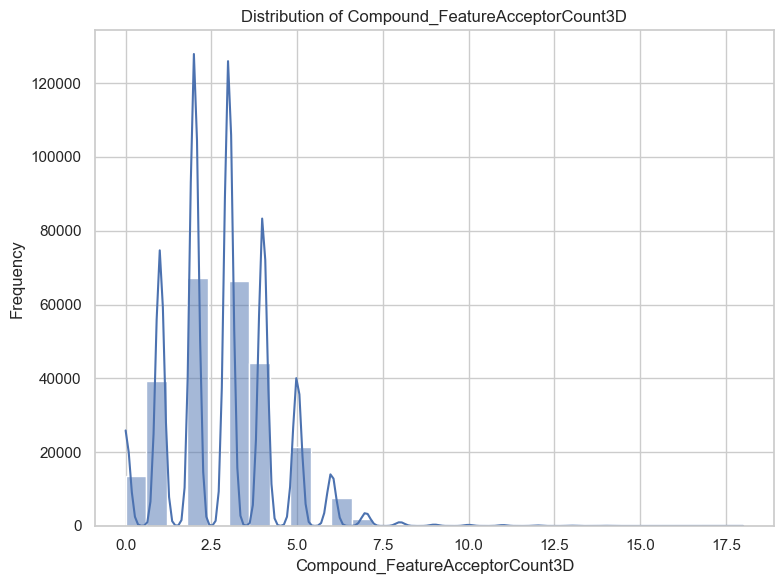

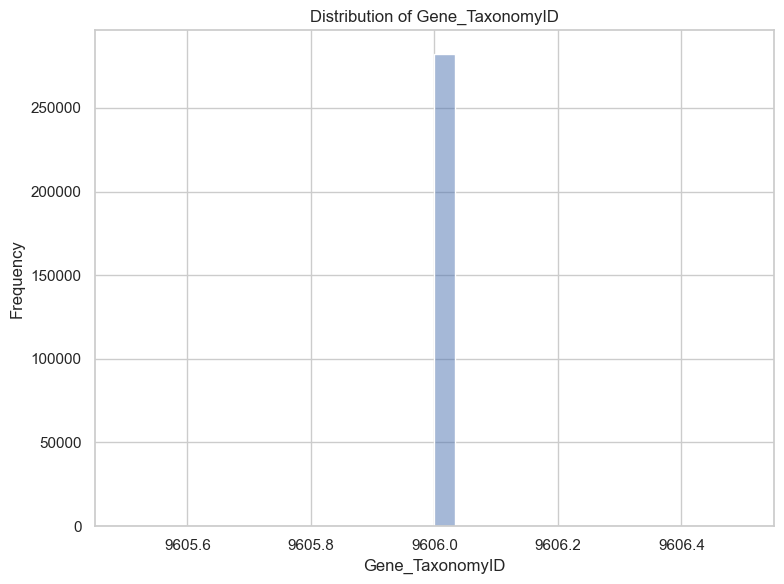

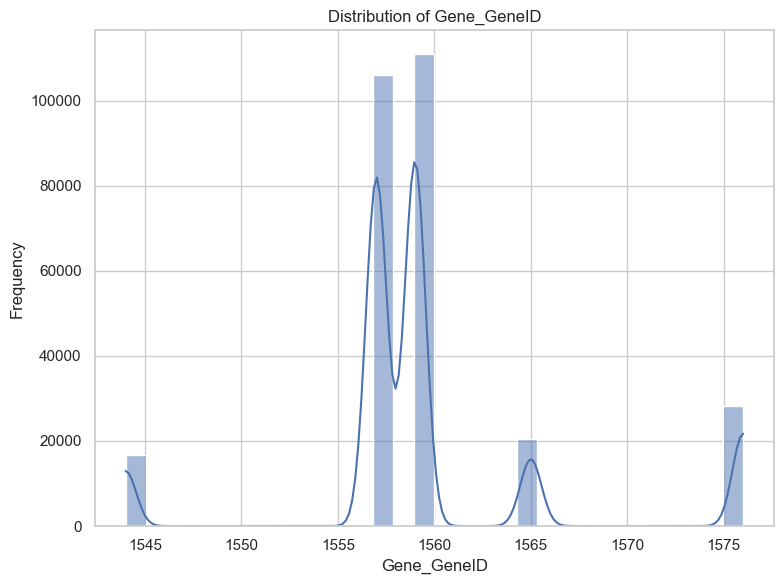

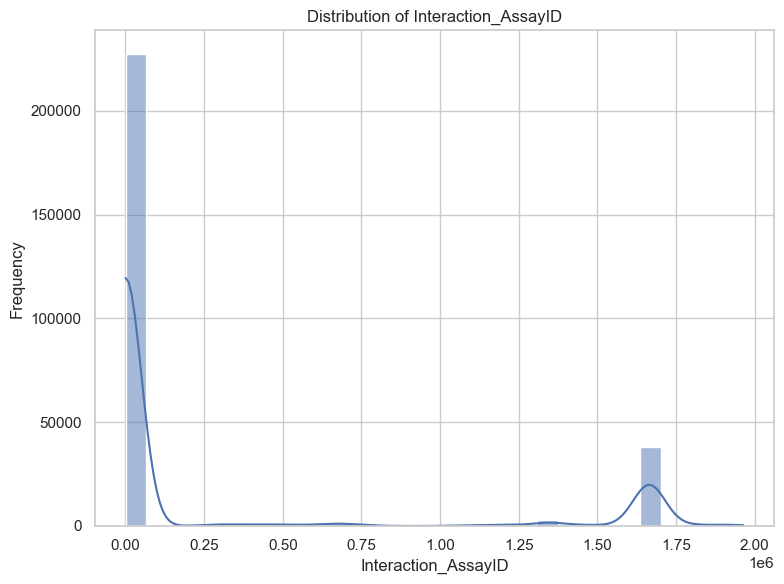

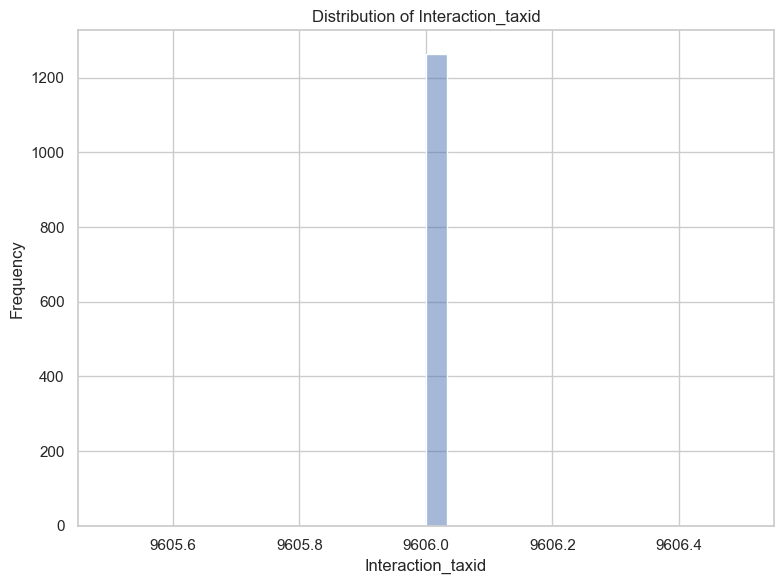

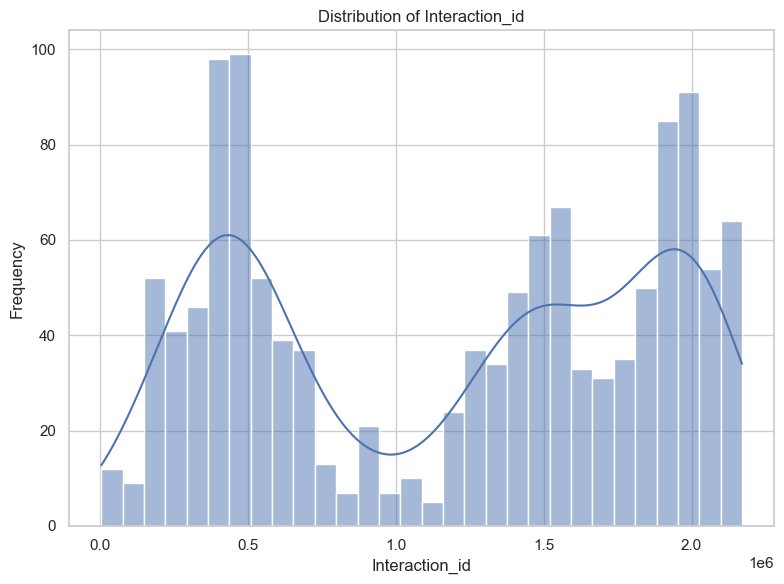

In [8]:
# Histograms: Distribution of numeric features (if any)
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

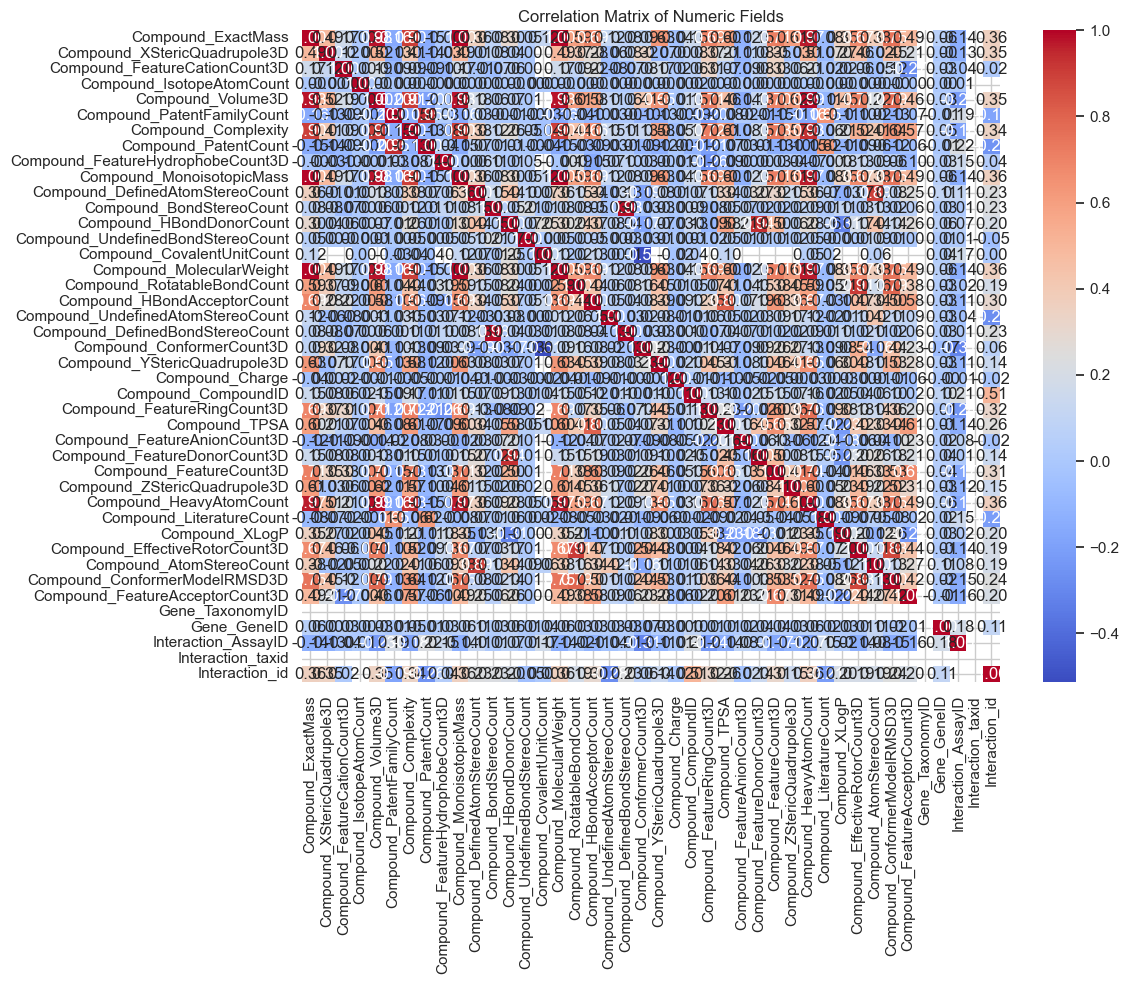

In [9]:
# Correlation heatmap (numeric fields only)
if len(numeric_cols) > 1:
    correlation_matrix = data[numeric_cols].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Matrix of Numeric Fields')
    plt.tight_layout()
    plt.show()

In [10]:
# Dominant interaction type per gene
dominant_interactions = interaction_counts.loc[
    interaction_counts.groupby('Gene_GeneSymbol')['Count'].idxmax()
]
dominant_interactions

,Gene_GeneSymbol,InteractionType,Count
0,CYP1A2,inactive,9015
7,CYP2C19,inactive,102028
15,CYP2C9,inactive,103670
21,CYP2D6,inactive,15161
29,CYP3A4,inactive,20574
